# Hybrid spelling and punctuation assistant

This notebook is the main experiment surface for the current project architecture.

The project uses one final system:

```text
HybridCorrector = candidate generator + top-k edit Transformer + source-aware punctuation head + RuBERT context reranker + quality guard
```

The model does not rewrite the whole sentence. It predicts local token edits from top-k candidates and source-aware punctuation labels. V11 uses CPU-first RuBERT reranking, safer runtime gates, rank-consistent top-k labels, narrow split/phrase candidates, source-aware candidate scoring, mined train-pair confusions, full word-decision diagnostics, morphology-guarded dictionary gates, candidate-aware KEEP training and clean-noise filtering. V11 excludes keyboard-neighbor candidates and uses orthographic and mined train-pair candidates while keeping conservative runtime guards.


## 1. Environment

In [16]:
import os
import sys
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Jupyter keeps imported modules in memory. After code changes we must force
# the kernel to import the current files from src/, otherwise old model classes
# can be used and cell 20 may fail while loading/evaluating the model.
PROJECT_MODULES = [
    "candidate_generator",
    "data_preparation",
    "edit_labels",
    "external_datasets",
    "evaluate_hybrid",
    "hybrid_corrector",
    "hybrid_model",
    "hybrid_preprocessor",
    "morphology_guard",
    "quality_guard",
    "text_utils",
    "train_hybrid",
    "training_augmentation",
]
def reload_project_modules(names=None):
    names = PROJECT_MODULES if names is None else names
    for module_name in names:
        sys.modules.pop(module_name, None)

reload_project_modules()

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TRANSFORMERS_NO_ADVISORY_WARNINGS", "1")
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "0"
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")
warnings.filterwarnings("ignore", message=".*Some weights of.*BertForMaskedLM.*")
try:
    from transformers.utils import logging as hf_logging
    hf_logging.set_verbosity_error()
except Exception:
    pass

import tensorflow as tf

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("Project root:", ROOT)

for folder in ["models", "report", "report/figures", "data/processed"]:
    Path(folder).mkdir(parents=True, exist_ok=True)


Python: 3.10.12
TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Project root: /home/daniil/projects/ai-assistant


## 2. Experiment Configuration

Change hyperparameters here before running the rest of the notebook.


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Data paths
DATASET_PATH = Path("data/processed/dataset.csv")
TRAIN_PATH = Path("data/processed/train.csv")
VAL_PATH = Path("data/processed/val.csv")
TEST_PATH = Path("data/processed/test.csv")
RAW_TEXTS_PATH = Path("data/raw/texts.txt")
EXTERNAL_DATA_DIR = Path("data/external")
EXTERNAL_AI_FOREVER_PATH = EXTERNAL_DATA_DIR / "ai_forever_spellcheck_punctuation_test.csv"
EXTERNAL_RUSPELLGOLD_PATH = EXTERNAL_DATA_DIR / "ruspellgold_test.csv"

# Dataset regeneration from data/raw/texts.txt + V10 real-pairs
REGENERATE_DATASET = True
ENABLE_REAL_PAIRS = True
SAMPLES_PER_TEXT = 4
TRAIN_CLEAN_RATIO = 0.35
EVAL_CLEAN_RATIO = 0.35
REAL_TRAIN_REPEAT = 6
REAL_VAL_RATIO = 0.10
REAL_MAX_CHARS = 240
REAL_MAX_TOKENS = 96
EXTERNAL_REAL_MAX_CHARS = 280
EXTERNAL_REAL_MAX_TOKENS = 128

TRAIN_CURRICULUM = [
    {"name": "orthography_rules", "profile": "orthography_rules", "p": 0.32},
    {"name": "punctuation_only", "profile": "punctuation_only", "p": 0.34},
    {"name": "punctuation_structural", "profile": "punctuation_structural", "p": 0.24},
    {"name": "mixed", "profile": "mixed", "p": 0.08},
    {"name": "hard", "profile": "hard", "p": 0.02},
]

EVAL_CURRICULUM = [
    {"name": "orthography_rules", "profile": "orthography_rules", "p": 0.32},
    {"name": "punctuation_only", "profile": "punctuation_only", "p": 0.34},
    {"name": "punctuation_structural", "profile": "punctuation_structural", "p": 0.24},
    {"name": "mixed", "profile": "mixed", "p": 0.08},
    {"name": "hard", "profile": "hard", "p": 0.02},
]

# Hybrid labels and model
MODEL_VERSION = 11
MAX_LENGTH = 128
MIN_VOCAB_FREQ = 1
MAX_VOCAB_SIZE = 80_000
CANDIDATE_MIN_FREQ = 1
CANDIDATE_MAX_DISTANCE = 1
LONG_OOV_MAX_DISTANCE = 2
LONG_OOV_MIN_LENGTH = 8
CANDIDATE_TOP_K = 16
MIN_DICTIONARY_SCORE = 0.25
SAFE_SPLIT_CANDIDATES = True
ENABLE_ORTHOGRAPHIC_CANDIDATES = True
ENABLE_MINED_CONFUSIONS = True
MINED_CONFUSION_MIN_COUNT = 2

D_MODEL = 128
NUM_HEADS = 4
FF_DIM = 256
NUM_LAYERS = 2
DROPOUT_RATE = 0.30
LEARNING_RATE = 1e-4

# Candidate-aware KEEP augmentation
KEEP_CANDIDATE_AUGMENTATION = True
KEEP_CANDIDATE_PROBABILITY = 0.35
KEEP_CANDIDATE_MAX_PER_EXAMPLE = 3
KEEP_CANDIDATE_MAX_SEARCHES = 50_000
KEEP_CANDIDATE_CLEAN_ONLY = True
CLEAN_AUDIT_MAX_WORD_SEARCHES = 5_000

# Action and punctuation training weights
CLEAN_ACTION_KEEP_WEIGHT = 2.0
DIRTY_ACTION_KEEP_WEIGHT = 0.8
ACTION_CHANGE_WEIGHT = 4.0
PUNCT_CHANGE_WEIGHT = 8.0
FINAL_PUNCT_WEIGHT = 8.0
CLEAN_PUNCT_KEEP_WEIGHT = 4.0
DIRTY_PUNCT_KEEP_WEIGHT = 1.0

# Training
BATCH_SIZE = 64
EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 2

# Context reranker
CONTEXT_RERANKER_ENABLED = True
CONTEXT_MODEL_NAME = "DeepPavlov/rubert-base-cased"
CONTEXT_DEVICE = "auto"  # uses CUDA for RuBERT when stable, falls back to CPU on scoring errors
CONTEXT_MARGIN = 0.25
USE_ENTITY_GUARD = True

# Evaluation
EVAL_SAMPLE_SIZE = None  # set None for full test split
EXTERNAL_EVAL_SAMPLE_SIZE = None
RUN_EXTERNAL_EVAL = True
WRITE_DIAGNOSTICS = True
INFERENCE_BATCH_SIZE = 512

EVAL_OUTPUT_DIR = Path("report/synthetic_v11")
STRICTNESS = "strict"  # strict | normal | aggressive
PUNCTUATION_MODE = "conservative"  # conservative | none | legacy

MODEL_PATH = Path("models/hybrid_corrector.keras")
PREPROCESSOR_PATH = Path("models/hybrid_preprocessor.pkl")
CANDIDATE_GENERATOR_PATH = Path("models/candidate_generator.pkl")
CONFIG_PATH = Path("models/hybrid_config.json")
TRAINING_LOG_PATH = Path("models/hybrid_training_log.csv")


## 3. Optional Dataset Regeneration

This cell uses the current project generator. V11 keeps generation conservative, with keyboard-neighbor candidates excluded and mined train-pair confusions enabled.


In [3]:
from data_preparation import DatasetGenerator, split_texts
from external_datasets import (
    build_ai_forever_external_eval,
    build_ai_forever_train_val,
    build_ruspellgold_external_eval,
)

real_train_stats = {}
external_ai_forever_stats = {}
external_ruspellgold_stats = {}

if REGENERATE_DATASET:
    if not RAW_TEXTS_PATH.exists():
        raise FileNotFoundError(f"Missing raw texts: {RAW_TEXTS_PATH}")

    generator = DatasetGenerator()
    texts = generator.load_texts_from_file(str(RAW_TEXTS_PATH))
    train_texts, val_texts, test_texts = split_texts(
        texts,
        train_ratio=0.8,
        val_ratio=0.1,
        test_ratio=0.1,
        seed=SEED,
    )

    df_train = generator.generate_dataset_curriculum(
        train_texts,
        samples_per_text=SAMPLES_PER_TEXT,
        clean_ratio=TRAIN_CLEAN_RATIO,
        curriculum=TRAIN_CURRICULUM,
    )
    df_train["split"] = "train"
    df_train = pd.concat([df_train, generator.curated_v10_examples("train")], ignore_index=True)

    df_val = generator.generate_dataset_curriculum(
        val_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=EVAL_CURRICULUM,
    )
    df_val["split"] = "val"
    df_val = pd.concat([df_val, generator.curated_v10_examples("val")], ignore_index=True)

    df_test = generator.generate_dataset_curriculum(
        test_texts,
        samples_per_text=1,
        clean_ratio=EVAL_CLEAN_RATIO,
        curriculum=EVAL_CURRICULUM,
    )
    df_test["split"] = "test"
    df_test = pd.concat([df_test, generator.curated_v10_examples("test")], ignore_index=True)

    if ENABLE_REAL_PAIRS:
        EXTERNAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
        real_train_df, real_val_df, real_train_stats = build_ai_forever_train_val(
            cache_dir=EXTERNAL_DATA_DIR,
            val_ratio=REAL_VAL_RATIO,
            repeat_train=REAL_TRAIN_REPEAT,
            seed=SEED,
            max_chars=REAL_MAX_CHARS,
            max_tokens=REAL_MAX_TOKENS,
        )
        print("AI Forever real train stats:", real_train_stats)
        df_train = pd.concat([df_train, real_train_df], ignore_index=True)
        df_val = pd.concat([df_val, real_val_df], ignore_index=True)

        external_ai_forever_df, external_ai_forever_stats = build_ai_forever_external_eval(
            cache_dir=EXTERNAL_DATA_DIR,
            max_chars=EXTERNAL_REAL_MAX_CHARS,
            max_tokens=EXTERNAL_REAL_MAX_TOKENS,
        )
        external_ruspellgold_df, external_ruspellgold_stats = build_ruspellgold_external_eval(
            cache_dir=EXTERNAL_DATA_DIR,
            max_chars=EXTERNAL_REAL_MAX_CHARS,
            max_tokens=EXTERNAL_REAL_MAX_TOKENS,
        )
        external_ai_forever_df.to_csv(EXTERNAL_AI_FOREVER_PATH, index=False, encoding="utf-8")
        external_ruspellgold_df.to_csv(EXTERNAL_RUSPELLGOLD_PATH, index=False, encoding="utf-8")
        print("External AI Forever rows:", len(external_ai_forever_df), external_ai_forever_stats, "->", EXTERNAL_AI_FOREVER_PATH)
        print("External RuSpellGold rows:", len(external_ruspellgold_df), external_ruspellgold_stats, "->", EXTERNAL_RUSPELLGOLD_PATH)

    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")

    print("Regenerated dataset:", len(df))
    print("Train/val/test:", len(df_train), len(df_val), len(df_test))
    if "source_kind" in df.columns:
        display(df.groupby(["split", "source_kind"]).size().rename("rows").reset_index())
else:
    print("Dataset regeneration skipped.")


Генерация датасета (CURRICULUM)...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47997/47997 [04:05<00:00, 195.76it/s]


Создано 191988 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5999/5999 [00:07<00:00, 772.03it/s]


Создано 5999 примеров (curriculum)
Генерация датасета (CURRICULUM)...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6001/6001 [00:08<00:00, 677.90it/s]


Создано 6001 примеров (curriculum)
AI Forever real train stats: {'input': 5569, 'kept': 3340, 'identical': 894, 'spacing_only': 158, 'not_edit_compatible': 74, 'untrainable_real_pair': 44, 'too_long': 846, 'morphology_or_grammar': 23, 'capitalization_only': 130, 'heavy_rewrite': 32, 'large_token_count_shift': 3, 'style_rewrite': 25, 'train_rows_before_repeat': 3006, 'train_rows_after_repeat': 18036, 'val_rows': 334}
External AI Forever rows: 5717 {'input': 8036, 'kept': 5717, 'too_long': 1030, 'morphology_or_grammar': 114, 'capitalization_only': 116, 'heavy_rewrite': 24, 'large_token_count_shift': 7, 'identical': 666, 'untrainable_real_pair': 103, 'style_rewrite': 115, 'spacing_only': 144} -> data/external/ai_forever_spellcheck_punctuation_test.csv
External RuSpellGold rows: 684 {'input': 1711, 'kept': 684, 'untrainable_real_pair': 8, 'identical': 767, 'too_long': 71, 'spacing_only': 160, 'capitalization_only': 9, 'morphology_or_grammar': 11, 'style_rewrite': 1} -> data/external/ruspel

,split,source_kind,rows
0,test,synthetic,6023
1,train,real,18036
2,train,synthetic,192010
3,val,real,334
4,val,synthetic,6021


## 4. Load And Inspect Dataset

Dataset rows: 222424
Train/val/test: 210046 6355 6023


,error_text,correct_text,difficulty,error_types,source_kind,source_dataset,source_domain,split
0,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",punctuation_structural,punct_remove_quotes,synthetic,synthetic,NaN,train
1,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",orthography_rules,clean,synthetic,synthetic,NaN,train
2,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",clean,clean,synthetic,synthetic,NaN,train
3,"Именно ему и приписывают авторство идеи, но са...","Именно ему и приписывают авторство идеи, но са...",orthography_rules,clean,synthetic,synthetic,NaN,train
4,По официальной информации Управления ветеринар...,По официальной информации Управления ветеринар...,punctuation_only,punct_remove_final,synthetic,synthetic,NaN,train


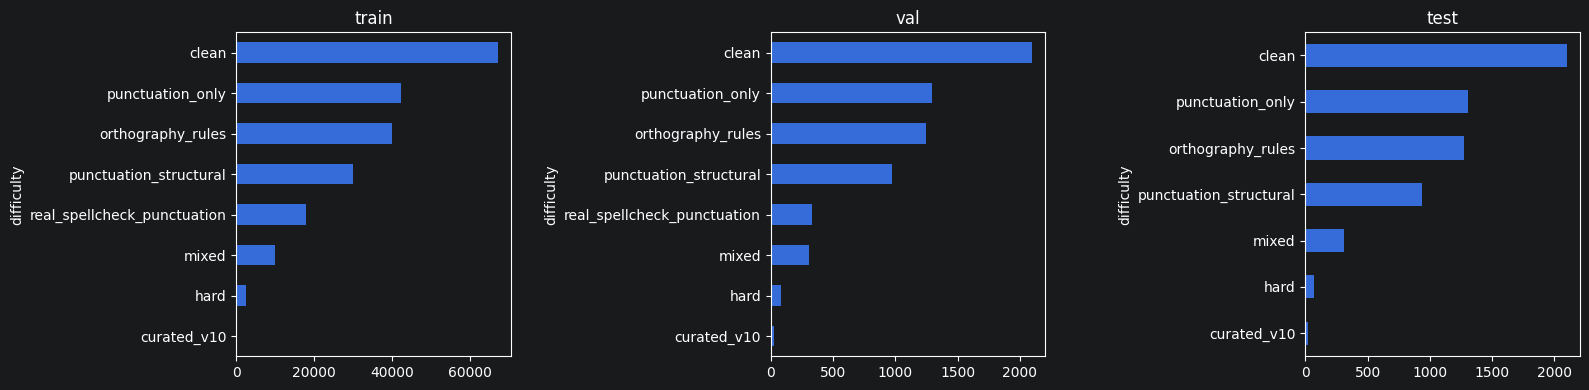

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")

df = pd.read_csv(DATASET_PATH, low_memory=False)
if "split" in df.columns:
    df_train = df[df["split"] == "train"].copy()
    df_val = df[df["split"] == "val"].copy()
    df_test = df[df["split"] == "test"].copy()
else:
    df_train = pd.read_csv(TRAIN_PATH)
    df_val = pd.read_csv(VAL_PATH)
    df_test = pd.read_csv(TEST_PATH)

print("Dataset rows:", len(df))
print("Train/val/test:", len(df_train), len(df_val), len(df_test))
display(df.head(5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, part, title in [
    (axes[0], df_train, "train"),
    (axes[1], df_val, "val"),
    (axes[2], df_test, "test"),
]:
    part["difficulty"].value_counts().sort_values().plot(kind="barh", ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


## 5. Build Hybrid Training Labels

In [5]:
reload_project_modules(["candidate_generator", "edit_labels", "training_augmentation", "text_utils", "morphology_guard"])
from candidate_generator import CandidateGenerator
from edit_labels import build_examples_from_dataframe
from training_augmentation import filter_noisy_clean_rows

provisional_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=False,
)

all_rows = pd.concat([df_train, df_val, df_test], ignore_index=True)
_, clean_noise_audit, suspicious_texts = filter_noisy_clean_rows(
    all_rows,
    provisional_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_noise_filter_path = Path("report/clean_noise_filter.csv")
clean_noise_audit.to_csv(clean_noise_filter_path, index=False, encoding="utf-8")
print("Clean noise filter rows:", len(clean_noise_audit), "->", clean_noise_filter_path)

if suspicious_texts:
    df_train = df_train.loc[~df_train["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_val = df_val.loc[~df_val["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df_test = df_test.loc[~df_test["correct_text"].astype(str).isin(suspicious_texts)].copy()
    df = pd.concat([df_train, df_val, df_test], ignore_index=True)
    df.to_csv(DATASET_PATH, index=False, encoding="utf-8")
    df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8")
    df_val.to_csv(VAL_PATH, index=False, encoding="utf-8")
    df_test.to_csv(TEST_PATH, index=False, encoding="utf-8")
    print("Filtered dataset rows:", len(df), "removed texts:", len(suspicious_texts))

train_examples, train_label_stats = build_examples_from_dataframe(df_train, max_tokens=MAX_LENGTH)
val_examples, val_label_stats = build_examples_from_dataframe(df_val, max_tokens=MAX_LENGTH)

print("Train label stats:", train_label_stats)
print("Val label stats:", val_label_stats)

if not train_examples or not val_examples:
    raise RuntimeError("Not enough aligned hybrid examples. Check dataset quality and MAX_LENGTH.")

if not hasattr(train_examples[0], "source_punct_labels"):
    raise RuntimeError("Stale edit_labels module detected. Rerun cell 2, then rerun cells 10-12.")

action_counter = Counter(label for ex in train_examples for label in ex.action_labels)
punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.target_punct_labels)
source_punct_counter = Counter(label or "NONE" for ex in train_examples for label in ex.source_punct_labels)

print("Action labels:", action_counter)
print("Source punctuation labels:", source_punct_counter)
print("Target punctuation labels:", punct_counter)
if len(clean_noise_audit):
    display(clean_noise_audit.head(10))


Clean noise filter rows: 795 -> report/clean_noise_filter.csv
Filtered dataset rows: 219657 removed texts: 795
Train label stats: {'rows': 207438, 'kept': 207438, 'skipped': 0, 'clean': 112069}
Val label stats: {'rows': 6288, 'kept': 6288, 'skipped': 0, 'clean': 3549}
Action labels: Counter({'KEEP': 2799623, 'REPLACE_0': 45113, 'DELETE': 872})
Source punctuation labels: Counter({'NONE': 2405233, ',': 209632, '.': 141290, '«': 21711, '"': 12528, '—': 10964, '(': 8060, '».': 5986, ':': 5396, ')': 5176, '?': 4031, '»,': 3472, '".': 2487, ').': 2168, '!': 1634, '...': 1612, '",': 1421, ':"': 832, ';': 513, ':«': 427, ',»': 407, ',"': 298, '!"': 83, '!»': 52, '?»': 45, '....': 42, '?"': 41, '."': 34, ':—': 18, '.»': 15})
Target punctuation labels: Counter({'NONE': 2347260, ',': 215897, '.': 183404, '«': 25173, '"': 12244, '—': 10360, '».': 9297, '(': 9063, ':': 5639, ')': 4580, '?': 4446, '»,': 4293, '".': 3918, ').': 3375, '",': 1554, '!': 1223, '...': 1128, ':"': 1102, ';': 516, ':«': 450

,word,candidate,candidate_score,candidate_distance,text
0,действующих,действующий,2.394449,1,Еще по предварительным итогам голосования стал...
1,посколько,поскольку,4.289716,1,"Дашкова: Я сейчас буду раздваиваться, поскольк..."
2,газоскреба,газоскреб,0.564949,1,Вишневский — «Высотная мания величия» Вы будет...
3,совершенным,совершенные,1.496508,1,"Так называемой «банде Боровикова», арестованно..."
4,месье,месте,5.013016,1,Изображенное тут же вмонтированное в стену кат...
5,открытым,открытый,2.043051,1,Пятитонный слон внезапно погнался за открытым ...
6,физлица,физлиц,0.833213,1,"Большинство сдают жилье как физлица, самозанят..."
7,личной,лично,3.459586,1,Одной из главных тем картины стала взаимосвязь...
8,следующей,следующий,3.796058,1,Референт начальника предприятия Геннадий Сорок...
9,основных,основные,2.744932,1,В 2001 году фильм был удостоен шести японских ...


## 6. Candidate Generator And Vectorization

In [6]:
reload_project_modules(["candidate_generator", "hybrid_preprocessor", "training_augmentation", "morphology_guard", "text_utils"])
from candidate_generator import CandidateGenerator
from hybrid_preprocessor import HybridPreprocessor
from training_augmentation import augment_contextual_phrase_examples, augment_keep_candidates, build_clean_candidate_audit, populate_top_k_candidates

candidate_generator = CandidateGenerator.from_texts(
    df_train["correct_text"].dropna().astype(str).tolist(),
    min_freq=CANDIDATE_MIN_FREQ,
    max_distance=CANDIDATE_MAX_DISTANCE,
    allow_split_candidates=SAFE_SPLIT_CANDIDATES,
    safe_split_only=True,
    long_oov_max_distance=LONG_OOV_MAX_DISTANCE,
    long_oov_min_length=LONG_OOV_MIN_LENGTH,
    enable_orthographic_candidates=ENABLE_ORTHOGRAPHIC_CANDIDATES,
    enable_mined_confusions=ENABLE_MINED_CONFUSIONS,
)
mined_confusion_stats = {"pairs": 0, "replace_segments": 0, "accepted": 0}
if ENABLE_MINED_CONFUSIONS:
    mining_rows = df_train.dropna(subset=["error_text", "correct_text"])
    mined_confusion_stats = candidate_generator.fit_mined_confusions(
        mining_rows["error_text"].astype(str).tolist(),
        mining_rows["correct_text"].astype(str).tolist(),
        min_count=MINED_CONFUSION_MIN_COUNT,
    )
print("Mined train confusions:", mined_confusion_stats)
candidate_generator.save(CANDIDATE_GENERATOR_PATH)
print("Candidate generator saved:", CANDIDATE_GENERATOR_PATH)
print("Known vocabulary size:", len(candidate_generator.frequencies))

clean_audit = build_clean_candidate_audit(
    pd.concat([df_train, df_val, df_test], ignore_index=True),
    candidate_generator,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    max_word_searches=CLEAN_AUDIT_MAX_WORD_SEARCHES,
)
clean_audit_path = Path("report/clean_candidate_audit.csv")
clean_audit.to_csv(clean_audit_path, index=False, encoding="utf-8")
print("Clean candidate audit rows:", len(clean_audit), "->", clean_audit_path)
if len(clean_audit):
    display(clean_audit.head(10))

train_examples, train_context_phrase_stats = augment_contextual_phrase_examples(
    train_examples,
    repeats=8,
    max_tokens=MAX_LENGTH,
)
val_examples, val_context_phrase_stats = augment_contextual_phrase_examples(
    val_examples,
    repeats=1,
    max_tokens=MAX_LENGTH,
)
print("Context phrase train examples:", train_context_phrase_stats)
print("Context phrase val examples:", val_context_phrase_stats)

train_examples, train_topk_candidate_stats = populate_top_k_candidates(
    train_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
val_examples, val_topk_candidate_stats = populate_top_k_candidates(
    val_examples,
    candidate_generator,
    candidate_top_k=CANDIDATE_TOP_K,
)
print("Top-k train candidate stats:", train_topk_candidate_stats)
print("Top-k val candidate stats:", val_topk_candidate_stats)
print("Train target rank distribution:", train_topk_candidate_stats.get("target_rank_distribution", {}))
print("Train candidate coverage:", train_topk_candidate_stats.get("candidate_coverage_rate"))

train_examples, train_keep_candidate_stats = augment_keep_candidates(
    train_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=KEEP_CANDIDATE_MAX_SEARCHES,
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
val_examples, val_keep_candidate_stats = augment_keep_candidates(
    val_examples,
    candidate_generator,
    enabled=KEEP_CANDIDATE_AUGMENTATION,
    probability=KEEP_CANDIDATE_PROBABILITY,
    max_per_example=KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    max_candidate_searches=max(1, KEEP_CANDIDATE_MAX_SEARCHES // 4),
    clean_only=KEEP_CANDIDATE_CLEAN_ONLY,
    seed=SEED + 1,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
)
print("Candidate-aware train KEEP stats:", train_keep_candidate_stats)
print("Candidate-aware val KEEP stats:", val_keep_candidate_stats)

preprocessor = HybridPreprocessor(
    max_length=MAX_LENGTH,
    min_freq=MIN_VOCAB_FREQ,
    max_vocab_size=MAX_VOCAB_SIZE,
    candidate_top_k=CANDIDATE_TOP_K,
)
preprocessor.fit(train_examples)
preprocessor.save(PREPROCESSOR_PATH)

x_train, y_train, sw_train = preprocessor.vectorize_examples(
    train_examples,
    clean_action_keep_weight=CLEAN_ACTION_KEEP_WEIGHT,
    dirty_action_keep_weight=DIRTY_ACTION_KEEP_WEIGHT,
    action_change_weight=ACTION_CHANGE_WEIGHT,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)
x_val, y_val, sw_val = preprocessor.vectorize_examples(
    val_examples,
    clean_action_keep_weight=CLEAN_ACTION_KEEP_WEIGHT,
    dirty_action_keep_weight=DIRTY_ACTION_KEEP_WEIGHT,
    action_change_weight=ACTION_CHANGE_WEIGHT,
    clean_punct_keep_weight=CLEAN_PUNCT_KEEP_WEIGHT,
    dirty_punct_keep_weight=DIRTY_PUNCT_KEEP_WEIGHT,
    punct_change_weight=PUNCT_CHANGE_WEIGHT,
    final_punct_weight=FINAL_PUNCT_WEIGHT,
)

if "source_punct_ids" not in x_train or x_train["candidate_ids"].ndim != 3:
    raise RuntimeError("Stale HybridPreprocessor detected. Rerun cell 2, then rerun cells 10-12.")

print("Hybrid vocab size:", preprocessor.vocab_size)
print("Candidate top-k:", preprocessor.candidate_top_k)
print("x_train token_ids:", x_train["token_ids"].shape)
print("x_train candidate_ids:", x_train["candidate_ids"].shape)
print("x_train source_punct_ids:", x_train["source_punct_ids"].shape)
print("y_train action:", y_train["action"].shape)
print("sample weights:", sw_train["action"].shape)


Mined train confusions: {'pairs': 207438, 'replace_segments': 36472, 'accepted': 1777}
Candidate generator saved: models/candidate_generator.pkl
Known vocabulary size: 87886
Clean candidate audit rows: 407 -> report/clean_candidate_audit.csv


,split,word,candidate,candidate_score,candidate_distance,source_known,text
0,train,свели,ввели,2.574711,1,True,"В 22 встречах девочки одержали 18 побед, свели..."
1,train,этого,того,6.263333,1,True,"До этого Гуцул допустила, что может баллотиров..."
2,train,чтобы,чтоб,2.962845,1,True,"Затем молодые родители расчленили тело, разлож..."
3,train,вынести,внести,2.574711,1,True,"Затем молодые родители расчленили тело, разлож..."
4,train,выделить,выделять,1.367296,1,True,В 2007 году планируется выделить 73 миллиона р...
5,train,также,такие,4.792344,1,True,В 2007 году планируется выделить 73 миллиона р...
6,train,больше,большое,3.370638,1,True,Компания объявила в официальном аккаунте на We...
7,train,известно,известны,2.844187,1,True,Об этом стало известно изданию «PrimaMedia.
8,train,никогда,некогда,2.110874,1,True,«Локомотив» никогда не выигрывал трофей.
9,train,вполне,волне,1.713572,1,True,"Даже сам маэстро утверждает, что его последние..."


Context phrase train examples: {'base_examples': 207438, 'added_examples': 160, 'clean_examples': 80, 'dirty_examples': 80, 'skipped_examples': 0}
Context phrase val examples: {'base_examples': 6288, 'added_examples': 20, 'clean_examples': 10, 'dirty_examples': 10, 'skipped_examples': 0}
Top-k train candidate stats: {'examples': 207598, 'tokens': 2846472, 'oracle_replace_tokens': 45193, 'target_candidate_hits': 30275, 'oracle_injected_tokens': 14918, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 63194, 'cache_hits': 2751086, 'candidate_searches': 95386, 'target_rank_distribution': {'0': 42801, '1': 2357, '2': 35}, 'context_phrase_candidate_tokens': 12549, 'candidate_coverage_rate': 0.6699046312482022, 'targeted_long_oov_hits': 13154}
Top-k val candidate stats: {'examples': 6308, 'tokens': 86669, 'oracle_replace_tokens': 1090, 'target_candidate_hits': 791, 'oracle_injected_tokens': 299, 'candidate_miss_tokens': 0, 'generated_candidate_tokens': 2149, 'cache_hits': 60189, 'can

## 7. Build Model

In [7]:
reload_project_modules(["hybrid_model"])
from hybrid_model import build_hybrid_model

model = build_hybrid_model(
    vocab_size=preprocessor.vocab_size,
    max_length=MAX_LENGTH,
    action_classes=preprocessor.action_classes,
    punct_classes=preprocessor.punct_classes,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    candidate_top_k=CANDIDATE_TOP_K,
)
input_names = {inp.name.split(":")[0].split("/")[-1] for inp in model.inputs}
if "source_punct_ids" not in input_names or "candidate_ids" not in input_names:
    raise RuntimeError("Model was built without V7 inputs. Rerun cell 2, then rerun cells 10-14.")
model.summary()


Model: "HybridEditPunctuationTransformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ candidate_ids       │ (None, 128, 16)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ source_punct_ids    │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_candidate_em… │ (None, 128, 128)  │ 20,764,800 │ token_ids[0][0],  │
│ (TokenCandidateEmb… │                   │            │ candidate_ids[0]… │
│                     │                   │            │ source_punct_ids… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_1     │ (None, 128, 128)  │    132,480 │ token_candidate_… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_2     │ (None, 128, 128)  │    132,480 │ encoder_block_1[… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 128, 128)  │          0 │ encoder_block_2[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ action (Dense)      │ (None, 128, 18)   │      2,322 │ shared_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punct (Dense)       │ (None, 128, 30)   │      3,870 │ shared_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,035,952 (80.25 MB)

 Trainable params: 21,035,952 (80.25 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train

This cell tracks train/validation loss and writes a CSV log to `models/hybrid_training_log.csv`.


In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger, TerminateOnNaN

callbacks = [
    EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=LR_PATIENCE, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(MODEL_PATH), monitor="val_loss", save_best_only=True, verbose=1),
    CSVLogger(str(TRAINING_LOG_PATH)),
    TerminateOnNaN(),
]

history = model.fit(
    x_train,
    y_train,
    sample_weight=sw_train,
    validation_data=(x_val, y_val, sw_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_PATH)
config = {
    "model_version": MODEL_VERSION,
    "requires_source_punct_ids": True,
    "requires_top_k_candidates": True,
    "requires_context_reranker": CONTEXT_RERANKER_ENABLED,
    "model_path": str(MODEL_PATH),
    "preprocessor_path": str(PREPROCESSOR_PATH),
    "candidate_generator_path": str(CANDIDATE_GENERATOR_PATH),
    "max_length": MAX_LENGTH,
    "max_vocab_size": MAX_VOCAB_SIZE,
    "vocab_size": preprocessor.vocab_size,
    "candidate_min_freq": CANDIDATE_MIN_FREQ,
    "candidate_max_distance": CANDIDATE_MAX_DISTANCE,
    "long_oov_max_distance": LONG_OOV_MAX_DISTANCE,
    "long_oov_min_length": LONG_OOV_MIN_LENGTH,
    "enable_orthographic_candidates": ENABLE_ORTHOGRAPHIC_CANDIDATES,
    "enable_mined_confusions": ENABLE_MINED_CONFUSIONS,
    "mined_confusion_min_count": MINED_CONFUSION_MIN_COUNT,
    "mined_confusion_stats": mined_confusion_stats,
    "candidate_top_k": CANDIDATE_TOP_K,
    "safe_split_candidates": SAFE_SPLIT_CANDIDATES,
    "min_dictionary_score": MIN_DICTIONARY_SCORE,
    "keep_candidate_augmentation": KEEP_CANDIDATE_AUGMENTATION,
    "keep_candidate_probability": KEEP_CANDIDATE_PROBABILITY,
    "keep_candidate_max_per_example": KEEP_CANDIDATE_MAX_PER_EXAMPLE,
    "keep_candidate_max_searches": KEEP_CANDIDATE_MAX_SEARCHES,
    "keep_candidate_clean_only": KEEP_CANDIDATE_CLEAN_ONLY,
    "clean_audit_max_word_searches": CLEAN_AUDIT_MAX_WORD_SEARCHES,
    "clean_action_keep_weight": CLEAN_ACTION_KEEP_WEIGHT,
    "dirty_action_keep_weight": DIRTY_ACTION_KEEP_WEIGHT,
    "action_change_weight": ACTION_CHANGE_WEIGHT,
    "punct_change_weight": PUNCT_CHANGE_WEIGHT,
    "final_punct_weight": FINAL_PUNCT_WEIGHT,
    "clean_punct_keep_weight": CLEAN_PUNCT_KEEP_WEIGHT,
    "dirty_punct_keep_weight": DIRTY_PUNCT_KEEP_WEIGHT,
    "context_reranker_enabled": CONTEXT_RERANKER_ENABLED,
    "context_model_name": CONTEXT_MODEL_NAME,
    "context_device": CONTEXT_DEVICE,
    "inference_batch_size": INFERENCE_BATCH_SIZE,
    "context_margin": CONTEXT_MARGIN,
    "use_entity_guard": USE_ENTITY_GUARD,
    "d_model": D_MODEL,
    "num_heads": NUM_HEADS,
    "ff_dim": FF_DIM,
    "num_layers": NUM_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "train_label_stats": train_label_stats,
    "val_label_stats": val_label_stats,
    "train_context_phrase_stats": train_context_phrase_stats,
    "val_context_phrase_stats": val_context_phrase_stats,
    "train_topk_candidate_stats": train_topk_candidate_stats,
    "val_topk_candidate_stats": val_topk_candidate_stats,
    "train_keep_candidate_stats": train_keep_candidate_stats,
    "val_keep_candidate_stats": val_keep_candidate_stats,
    "real_pairs_enabled": ENABLE_REAL_PAIRS,
    "real_train_repeat": REAL_TRAIN_REPEAT,
    "real_val_ratio": REAL_VAL_RATIO,
    "real_train_stats": real_train_stats,
    "external_ai_forever_path": str(EXTERNAL_AI_FOREVER_PATH),
    "external_ai_forever_stats": external_ai_forever_stats,
    "external_ruspellgold_path": str(EXTERNAL_RUSPELLGOLD_PATH),
    "external_ruspellgold_stats": external_ruspellgold_stats,
    "clean_candidate_audit_path": str(clean_audit_path),
    "clean_noise_filter_path": str(clean_noise_filter_path),
    "clean_noise_filter_rows": int(len(clean_noise_audit)),
    "clean_noise_filter_texts": int(len(suspicious_texts)),
    "best_val_loss": float(min(history.history["val_loss"])),
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved model:", MODEL_PATH)
print("Saved config:", CONFIG_PATH)


Epoch 1/30
3244/3244 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - action_acc: 0.7199 - action_loss: 0.0276 - loss: 0.0812 - punct_acc: 0.8701 - punct_loss: 0.1531
Epoch 1: val_loss improved from None to 0.03136, saving model to models/hybrid_corrector.keras
3244/3244 ━━━━━━━━━━━━━━━━━━━━ 115s 25ms/step - action_acc: 0.6758 - action_loss: 0.0156 - loss: 0.0487 - punct_acc: 0.8988 - punct_loss: 0.0944 - val_action_acc: 0.9817 - val_action_loss: 0.0139 - val_loss: 0.0314 - val_punct_acc: 0.9974 - val_punct_loss: 0.0502 - learning_rate: 1.0000e-04
Epoch 2/30
3243/3244 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - action_acc: 0.9167 - action_loss: 0.0052 - loss: 0.0217 - punct_acc: 0.9612 - punct_loss: 0.0473
Epoch 2: val_loss improved from 0.03136 to 0.02887, saving model to models/hybrid_corrector.keras
3244/3244 ━━━━━━━━━━━━━━━━━━━━ 53s 16ms/step - action_acc: 0.9506 - action_loss: 0.0045 - loss: 0.0197 - punct_acc: 0.9466 - punct_loss: 0.0432 - val_action_acc: 0.9957 - val_action_loss: 0.0116 - val_loss: 

## 9. Training Curves

,action_acc,action_loss,loss,punct_acc,punct_loss,val_action_acc,val_action_loss,val_loss,val_punct_acc,val_punct_loss,learning_rate
2,0.987685,0.002912,0.013627,0.900447,0.030614,0.995164,0.013802,0.031891,0.983091,0.052005,0.000100
3,0.991997,0.002147,0.010195,0.885898,0.022993,0.997073,0.011714,0.031077,0.914185,0.055604,0.000100
4,0.992845,0.001579,0.007561,0.903546,0.017091,0.995929,0.012754,0.033263,0.995596,0.058873,0.000050
5,0.992004,0.001371,0.006501,0.919037,0.014654,0.997114,0.013093,0.034206,0.984001,0.060570,0.000050
6,0.991226,0.001188,0.005545,0.925378,0.012448,0.996561,0.013210,0.035362,0.993494,0.063549,0.000025


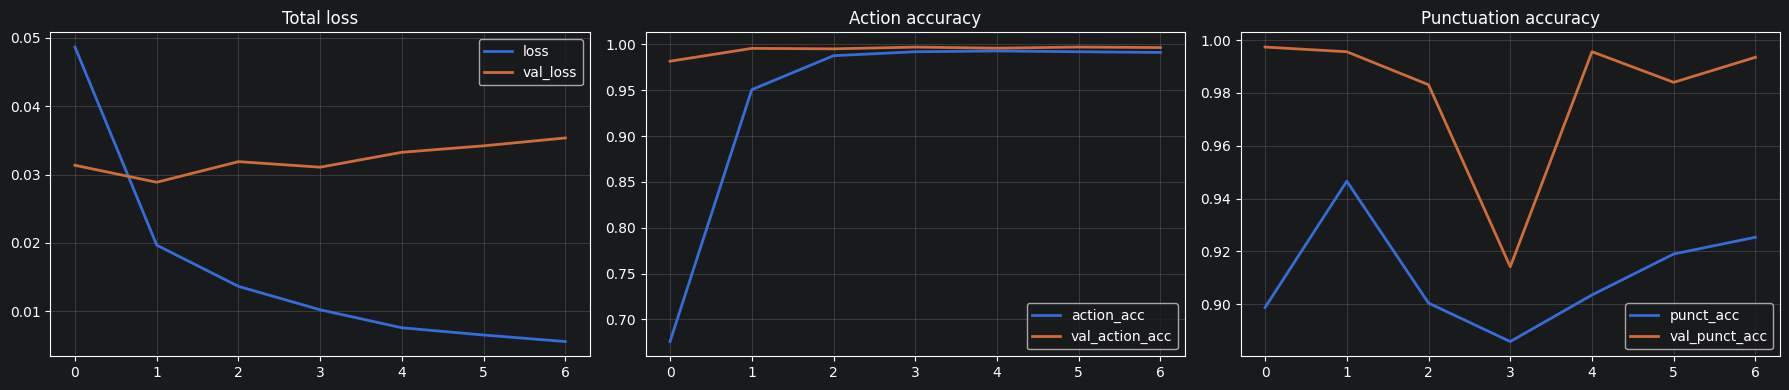

In [9]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0], linewidth=2)
axes[0].set_title("Total loss")
axes[0].grid(True, alpha=0.3)

for col in ["action_acc", "val_action_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[1], linewidth=2, label=col)
axes[1].set_title("Action accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for col in ["punct_acc", "val_punct_acc"]:
    if col in history_df:
        history_df[col].plot(ax=axes[2], linewidth=2, label=col)
axes[2].set_title("Punctuation accuracy")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10.1 Evaluate


In [10]:
# Reload project modules before evaluation. This prevents stale Jupyter imports
# from trying to load a model with an old class definition.
reload_project_modules()

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Missing model config: {CONFIG_PATH}. Run training cell 16 first.")

model_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
if model_config.get("model_version", 0) < 11:
    raise RuntimeError(
        "The saved model is obsolete for the V11 runtime. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )
if not model_config.get("requires_source_punct_ids", False) or not model_config.get("requires_top_k_candidates", False):
    raise RuntimeError(
        "The saved model is from an old input format. "
        "Restart/rerun the notebook from the environment/config cells through the training cell, then run evaluation again."
    )

from evaluate_hybrid import evaluate_hybrid

summary = evaluate_hybrid(
    dataset_path=str(TEST_PATH),
    sample_size=EVAL_SAMPLE_SIZE,
    output_dir=str(EVAL_OUTPUT_DIR),
    strictness=STRICTNESS,
    punctuation_mode=PUNCTUATION_MODE,
    min_dictionary_score=MIN_DICTIONARY_SCORE,
    candidate_top_k=CANDIDATE_TOP_K,
    context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
    context_model_name=CONTEXT_MODEL_NAME,
    context_device=CONTEXT_DEVICE,
    context_margin=CONTEXT_MARGIN,
    use_entity_guard=USE_ENTITY_GUARD,
    write_diagnostics=WRITE_DIAGNOSTICS,
    inference_batch_size=INFERENCE_BATCH_SIZE,
)
summary


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 512/5931 examples
Corrected 1024/5931 examples
Corrected 1536/5931 examples
Corrected 2048/5931 examples
Corrected 2560/5931 examples
Corrected 3072/5931 examples
Corrected 3584/5931 examples
Corrected 4096/5931 examples
Corrected 4608/5931 examples
Corrected 5120/5931 examples
Corrected 5632/5931 examples
Corrected 5931/5931 examples
Evaluated 50/5931 examples
Evaluated 100/5931 examples
Evaluated 150/5931 examples
Evaluated 200/5931 examples
Evaluated 250/5931 examples
Evaluated 300/5931 examples
Evaluated 350/5931 examples
Evaluated 400/5931 examples
Evaluated 450/5931 examples
Evaluated 500/5931 examples
Evaluated 550/5931 examples
Evaluated 600/5931 examples
Evaluated 650/5931 examples
Evaluated 700/5931 examples
Evaluated 750/5931 examples
Evaluated 800/5931 examples
Evaluated 850/5931 examples
Evaluated 900/5931 examples
Evaluated 950/5931 examples
Evaluated 1000/5931 examples
Evaluated 1050/5931 examples
Evaluated 1100/5931 examples
Evaluated 1150/5931 examples
Evalua

{'examples': 5931,
 'exact_match': 0.7083122576294049,
 'mean_input_cer': 0.005423725217467241,
 'mean_pred_cer': 0.0038987314757461663,
 'mean_cer_delta': 0.0015249937417210746,
 'improved_rate': 0.13218681503962232,
 'worse_rate': 0.013657056145675266,
 'unchanged_rate': 0.8524700725004215,
 'unchanged_wrong_rate': 0.6529584557280739,
 'clean_overcorrection_rate': 0.013528748590755355,
 'word_overcorrection_rate': 0.0,
 'punct_overcorrection_rate': 0.013528748590755355,
 'punct_input_similarity': 0.8789437503791115,
 'punct_pred_similarity': 0.9155849713865971,
 'punct_similarity_delta': 0.03664122100748557,
 'mean_punct_count_error': 0.270612038442084,
 'mean_confidence': 0.9865662408263295,
 'accepted_rate': 0.9959534648457259,
 'layout_changed_without_edits_count': 0,
 'clean_slice': {'examples': 3548,
  'exact_match': 0.9864712514092446,
  'mean_input_cer': 0.0,
  'mean_pred_cer': 0.00015177419845982822,
  'mean_cer_delta': -0.00015177419845982822,
  'improved_rate': 0.0,
  'wors

## 10.2 External Evaluation

Runs held-out real spellcheck/punctuation benchmarks without mixing them into the synthetic test split.


In [11]:
external_summaries = {}

if RUN_EXTERNAL_EVAL:
    external_eval_jobs = [
        ("ai_forever_full", EXTERNAL_AI_FOREVER_PATH, "report/external_ai_forever_v11", None),
        ("ruspellgold", EXTERNAL_RUSPELLGOLD_PATH, "report/external_ruspellgold_v11", EXTERNAL_EVAL_SAMPLE_SIZE),
    ]
    for name, path, output_dir, sample_size in external_eval_jobs:
        if not Path(path).exists():
            print(f"External eval skipped for {name}: missing {path}")
            continue
        external_summaries[name] = evaluate_hybrid(
            dataset_path=str(path),
            sample_size=sample_size,
            output_dir=output_dir,
            strictness=STRICTNESS,
            punctuation_mode=PUNCTUATION_MODE,
            min_dictionary_score=MIN_DICTIONARY_SCORE,
            candidate_top_k=CANDIDATE_TOP_K,
            context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
            context_model_name=CONTEXT_MODEL_NAME,
            context_device=CONTEXT_DEVICE,
            context_margin=CONTEXT_MARGIN,
            use_entity_guard=USE_ENTITY_GUARD,
            write_diagnostics=WRITE_DIAGNOSTICS,
            inference_batch_size=INFERENCE_BATCH_SIZE,
        )
    display(pd.DataFrame(external_summaries).T) if external_summaries else print("External eval skipped.")
else:
    print("External eval disabled.")

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 512/5717 examples
Corrected 1024/5717 examples
Corrected 1536/5717 examples
Corrected 2048/5717 examples
Corrected 2560/5717 examples
Corrected 3072/5717 examples
Corrected 3584/5717 examples
Corrected 4096/5717 examples
Corrected 4608/5717 examples
Corrected 5120/5717 examples
Corrected 5632/5717 examples
Corrected 5717/5717 examples
Evaluated 50/5717 examples
Evaluated 100/5717 examples
Evaluated 150/5717 examples
Evaluated 200/5717 examples
Evaluated 250/5717 examples
Evaluated 300/5717 examples
Evaluated 350/5717 examples
Evaluated 400/5717 examples
Evaluated 450/5717 examples
Evaluated 500/5717 examples
Evaluated 550/5717 examples
Evaluated 600/5717 examples
Evaluated 650/5717 examples
Evaluated 700/5717 examples
Evaluated 750/5717 examples
Evaluated 800/5717 examples
Evaluated 850/5717 examples
Evaluated 900/5717 examples
Evaluated 950/5717 examples
Evaluated 1000/5717 examples
Evaluated 1050/5717 examples
Evaluated 1100/5717 examples
Evaluated 1150/5717 examples
Evalua

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 512/684 examples
Corrected 684/684 examples
Evaluated 50/684 examples
Evaluated 100/684 examples
Evaluated 150/684 examples
Evaluated 200/684 examples
Evaluated 250/684 examples
Evaluated 300/684 examples
Evaluated 350/684 examples
Evaluated 400/684 examples
Evaluated 450/684 examples
Evaluated 500/684 examples
Evaluated 550/684 examples
Evaluated 600/684 examples
Evaluated 650/684 examples
{
  "examples": 684,
  "exact_match": 0.05847953216374269,
  "mean_input_cer": 0.01913716986722405,
  "mean_pred_cer": 0.018652439458926903,
  "mean_cer_delta": 0.00048473040829714436,
  "improved_rate": 0.1023391812865497,
  "worse_rate": 0.06432748538011696,
  "unchanged_rate": 0.8201754385964912,
  "unchanged_wrong_rate": 0.8201754385964912,
  "clean_overcorrection_rate": null,
  "word_overcorrection_rate": null,
  "punct_overcorrection_rate": null,
  "punct_input_similarity": 0.9105194899904742,
  "punct_pred_similarity": 0.9072566656980343,
  "punct_similarity_delta": -0.0032628242924

,examples,exact_match,mean_input_cer,mean_pred_cer,mean_cer_delta,improved_rate,worse_rate,unchanged_rate,unchanged_wrong_rate,clean_overcorrection_rate,...,low_action_dictionary_recovery_count,safe_comma_delete_recovery_count,safe_service_comma_delete_recovery_count,safe_date_comma_delete_recovery_count,safe_final_period_recovery_count,comma_delete_blocked_count,comma_insert_blocked_count,split_candidate_accept_rate,internal_period_overcorrection_rate,punct_wrong_period_to_comma_improved_rate
ai_forever_full,5717,0.019241,0.062327,0.058883,0.003443,0.213224,0.029386,0.742172,0.742172,None,...,20,0,0,0,376,296,1159,None,0.0,None
ruspellgold,684,0.05848,0.019137,0.018652,0.000485,0.102339,0.064327,0.820175,0.820175,None,...,5,0,0,0,6,86,228,None,0.0,None


## 11. Analyze Reports

In [12]:
summary_path = EVAL_OUTPUT_DIR / "summary.json"
analysis_path = EVAL_OUTPUT_DIR / "error_analysis.csv"
by_type_path = EVAL_OUTPUT_DIR / "error_metrics_by_type.csv"
worst_path = EVAL_OUTPUT_DIR / "worst_cases.csv"
punct_diag_path = EVAL_OUTPUT_DIR / "punct_edit_diagnostics.csv"
word_decision_path = EVAL_OUTPUT_DIR / "word_decision_diagnostics.csv"

if summary_path.exists():
    print(summary_path.read_text(encoding="utf-8"))

analysis_df = pd.read_csv(analysis_path) if analysis_path.exists() else pd.DataFrame()
by_type_df = pd.read_csv(by_type_path) if by_type_path.exists() else pd.DataFrame()
worst_df = pd.read_csv(worst_path) if worst_path.exists() else pd.DataFrame()
punct_diag_df = pd.read_csv(punct_diag_path) if punct_diag_path.exists() else pd.DataFrame()
word_decision_df = pd.read_csv(word_decision_path) if word_decision_path.exists() else pd.DataFrame()

print("Analysis rows:", len(analysis_df))
if not analysis_df.empty:
    clean_df = analysis_df[analysis_df["input_cer"] == 0]
    dirty_df = analysis_df[analysis_df["input_cer"] > 0]
    quality_rows = []
    for name, part in [("clean", clean_df), ("dirty", dirty_df), ("all", analysis_df)]:
        if part.empty:
            continue
        quality_rows.append({
            "slice": name,
            "examples": len(part),
            "mean_input_cer": part["input_cer"].mean(),
            "mean_pred_cer": part["pred_cer"].mean(),
            "mean_cer_delta": part["cer_delta"].mean(),
            "worse_rate": part["worse"].mean(),
            "clean_overcorrection_rate": part["clean_overcorrection"].mean() if name == "clean" else np.nan,
            "word_overcorrection_rate": part["word_overcorrection"].mean() if name == "clean" and "word_overcorrection" in part else np.nan,
            "punct_overcorrection_rate": part["punct_overcorrection"].mean() if name == "clean" and "punct_overcorrection" in part else np.nan,
            "layout_changed_without_edits": part["layout_changed_without_edits"].sum() if "layout_changed_without_edits" in part else np.nan,
            "punct_similarity_delta": part["punct_pred_similarity"].mean() - part["punct_input_similarity"].mean(),
            "accepted_rate": part["accepted"].mean(),
        })
    display(pd.DataFrame(quality_rows))

if not by_type_df.empty:
    display(by_type_df.head(20))
if not worst_df.empty:
    columns = [
        "error_types", "input_cer", "pred_cer", "cer_delta", "guard_reason",
        "word_edit_count", "punct_edit_count", "error_text", "predicted_text", "correct_text",
    ]
    display(worst_df[[c for c in columns if c in worst_df.columns]].head(20))


if not word_decision_df.empty:
    print("Word decision diagnostics rows:", len(word_decision_df))
    display(word_decision_df["blocked_reason"].value_counts(dropna=False).head(20).to_frame("count"))
    if "target_present_but_not_applied" in word_decision_df:
        display(word_decision_df[word_decision_df["target_present_but_not_applied"] == True].head(20))
    display(word_decision_df.head(20))

if not punct_diag_df.empty:
    print("Punctuation diagnostics rows:", len(punct_diag_df))
    display(punct_diag_df["blocked_reason"].value_counts(dropna=False).head(20).to_frame("count"))
    for column in ["protected_gap", "punct_position_type", "window_conflict_resolved"]:
        if column in punct_diag_df:
            display(punct_diag_df[column].value_counts(dropna=False).head(10).to_frame("count"))
    display(punct_diag_df.head(20))

print("Full test command after training:")
print(
    "PYTHONPATH=src .venv/bin/python src/evaluate.py "
    "--dataset data/processed/test.csv --all --output-dir report/synthetic_v11 "
    "--strictness strict --punctuation-mode conservative --candidate-top-k 16 "
    "--context-device auto --no-diagnostics --inference-batch-size 512"
)

# V11 comparison table: keep old V10.5 summaries next to fresh V11 runs.
summary_jobs = {
    "synthetic_v10_5": Path("report/synthetic_v10_5/summary.json"),
    "synthetic_v11": Path("report/synthetic_v11/summary.json"),
    "ai_forever_v10_5_sample": Path("report/external_ai_forever_v10_5_sample/summary.json"),
    "ai_forever_v11_full": Path("report/external_ai_forever_v11/summary.json"),
    "ruspellgold_v10_5": Path("report/external_ruspellgold_v10_5/summary.json"),
    "ruspellgold_v11": Path("report/external_ruspellgold_v11/summary.json"),
}
comparison_rows = []
for name, path in summary_jobs.items():
    if not path.exists():
        continue
    item = json.loads(path.read_text(encoding="utf-8"))
    comparison_rows.append({
        "run": name,
        "runtime_version": item.get("runtime_version"),
        "model_name": item.get("model_name", "hybrid"),
        "examples": item.get("examples"),
        "exact_match": item.get("exact_match"),
        "mean_cer_delta": item.get("mean_cer_delta"),
        "improved_rate": item.get("improved_rate"),
        "worse_rate": item.get("worse_rate"),
        "candidate_coverage_rate": item.get("candidate_coverage_rate"),
        "target_present_but_not_applied_rate": item.get("target_present_but_not_applied_rate"),
        "clean_overcorrection_rate": item.get("clean_overcorrection_rate"),
        "word_overcorrection_rate": item.get("word_overcorrection_rate"),
        "punct_overcorrection_rate": item.get("punct_overcorrection_rate"),
        "generation_empty_rate": item.get("generation_empty_rate"),
        "input_fallback_rate": item.get("input_fallback_rate"),
    })
if comparison_rows:
    display(pd.DataFrame(comparison_rows))

if not word_decision_df.empty:
    target_absent = word_decision_df[(word_decision_df["target_is_replace"] == True) & (word_decision_df["target_present"] == False)]
    target_blocked = word_decision_df[word_decision_df.get("target_present_but_not_applied", False) == True]
    wrong_split = word_decision_df[word_decision_df["candidate_sources"].astype(str).str.contains("split|phrase_safe", regex=True, na=False)]
    for title, frame in [
        ("target absent", target_absent),
        ("target present but blocked", target_blocked),
        ("split/phrase-safe decisions", wrong_split),
    ]:
        print(title, len(frame))
        display(frame.head(20))

if not punct_diag_df.empty:
    punct_regressions = punct_diag_df[(punct_diag_df["row_worse"] == True) & (punct_diag_df["applied"] == True)]
    print("punctuation regression decisions", len(punct_regressions))
    display(punct_regressions.head(20))

{
  "examples": 5931,
  "exact_match": 0.7083122576294049,
  "mean_input_cer": 0.005423725217467241,
  "mean_pred_cer": 0.0038987314757461663,
  "mean_cer_delta": 0.0015249937417210746,
  "improved_rate": 0.13218681503962232,
  "worse_rate": 0.013657056145675266,
  "unchanged_rate": 0.8524700725004215,
  "unchanged_wrong_rate": 0.6529584557280739,
  "clean_overcorrection_rate": 0.013528748590755355,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.013528748590755355,
  "punct_input_similarity": 0.8789437503791115,
  "punct_pred_similarity": 0.9155849713865971,
  "punct_similarity_delta": 0.03664122100748557,
  "mean_punct_count_error": 0.270612038442084,
  "mean_confidence": 0.9865662408263295,
  "accepted_rate": 0.9959534648457259,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 3548,
    "exact_match": 0.9864712514092446,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.00015177419845982822,
    "mean_cer_delta": -0.000151774198459828

,slice,examples,mean_input_cer,mean_pred_cer,mean_cer_delta,worse_rate,clean_overcorrection_rate,word_overcorrection_rate,punct_overcorrection_rate,layout_changed_without_edits,punct_similarity_delta,accepted_rate
0,clean,3548,0.000000,0.000152,-0.000152,0.013529,0.013529,0.0,0.013529,0,-0.002152,0.996618
1,dirty,2383,0.013499,0.009477,0.004021,0.013848,NaN,NaN,NaN,0,0.094400,0.994964
2,all,5931,0.005424,0.003899,0.001525,0.013657,NaN,NaN,NaN,0,0.036641,0.995953


,examples,exact_match,mean_input_cer,mean_pred_cer,mean_cer_delta,improved_rate,worse_rate,unchanged_rate,unchanged_wrong_rate,clean_overcorrection_rate,word_overcorrection_rate,punct_overcorrection_rate,punct_input_similarity,punct_pred_similarity,punct_similarity_delta,mean_punct_count_error,mean_confidence,accepted_rate,layout_changed_without_edits_count,error_type
0,3548,0.986471,0.000000,0.000152,-0.000152,0.000000,0.013529,0.986471,NaN,0.013529,0.0,0.013529,1.000000,0.997848,-0.002152,0.013529,0.986669,0.996618,0,clean
1,102,0.000000,0.011269,0.011283,-0.000014,0.019608,0.019608,0.960784,0.960784,NaN,NaN,NaN,0.785528,0.783171,-0.002358,1.039216,0.981039,1.000000,0,punct_extra_comma_before_single_i
2,249,0.016064,0.013197,0.012617,0.000580,0.140562,0.068273,0.787149,0.787149,NaN,NaN,NaN,0.944328,0.953900,0.009572,0.156627,0.981140,0.995984,0,spelling_suffix_pronunciation
3,35,0.000000,0.021934,0.021313,0.000621,0.028571,0.000000,0.971429,0.971429,NaN,NaN,NaN,0.631541,0.636643,0.005102,2.085714,0.989216,0.942857,0,punct_bracket_pair_missing
4,18,0.055556,0.012079,0.011421,0.000658,0.111111,0.000000,0.888889,0.888889,NaN,NaN,NaN,0.814645,0.822581,0.007937,1.000000,0.979465,1.000000,0,punct_remove_homogeneous_comma
5,11,0.000000,0.024619,0.023710,0.000909,0.090909,0.000000,0.909091,0.909091,NaN,NaN,NaN,0.832667,0.842584,0.009917,1.090909,0.978104,1.000000,0,punct_bsp_dash_missing
6,15,0.000000,0.013106,0.012114,0.000992,0.133333,0.000000,0.866667,0.866667,NaN,NaN,NaN,0.981538,0.994872,0.013333,0.066667,0.987271,1.000000,0,spelling_ne_ni
7,118,0.016949,0.026049,0.024815,0.001234,0.101695,0.016949,0.872881,0.872881,NaN,NaN,NaN,0.608614,0.639240,0.030626,2.135593,0.987675,0.949153,0,punct_remove_quotes
8,32,0.062500,0.026450,0.022862,0.003587,0.093750,0.000000,0.875000,0.875000,NaN,NaN,NaN,0.768439,0.802293,0.033854,1.062500,0.989302,1.000000,0,punct_dash_extra
9,203,0.325123,0.011715,0.007678,0.004036,0.394089,0.029557,0.551724,0.551724,NaN,NaN,NaN,0.765081,0.862774,0.097693,0.733990,0.987238,0.990148,0,punct_remove_comma_before_clause


,error_types,input_cer,pred_cer,cer_delta,guard_reason,word_edit_count,punct_edit_count,error_text,predicted_text,correct_text
0,spelling_abbreviation_case,0.107143,0.142857,-0.035714,accepted,0,1,Этот вуз открыл лабораторию.,"Этот вуз, открыл лабораторию.",Этот ВУЗ открыл лабораторию.
1,clean,0.000000,0.024390,-0.024390,accepted,0,1,"Немцы ругаются, что греки плохо работают.","Немцы ругаются, что греки, плохо работают.","Немцы ругаются, что греки плохо работают."
2,clean,0.000000,0.023256,-0.023256,accepted,0,1,Мороз и солнце – это о погоде в Петербурге.,"Мороз, и солнце – это о погоде в Петербурге.",Мороз и солнце – это о погоде в Петербурге.
3,clean,0.000000,0.020000,-0.020000,accepted,0,1,"«Не знаю даже, что сказать», – недоумевают дру...","«Не знаю, даже, что сказать», – недоумевают др...","«Не знаю даже, что сказать», – недоумевают дру..."
4,clean,0.000000,0.019231,-0.019231,accepted,0,1,"Хорошо жить стали и поняли, что ничего не изме...","Хорошо, жить стали и поняли, что ничего не изм...","Хорошо жить стали и поняли, что ничего не изме..."
5,punct_remove_comma_before_clause,0.017857,0.035714,-0.017857,accepted,0,1,Казалось бы что может изменить внутренний мир ...,"Казалось, бы что может изменить внутренний мир...","Казалось бы, что может изменить внутренний мир..."
6,clean,0.000000,0.017857,-0.017857,accepted,0,1,"Пострадавших в обоих случаях нет, отметил глав...","Пострадавших в обоих случаях нет, отметил, гла...","Пострадавших в обоих случаях нет, отметил глав..."
7,clean,0.000000,0.016667,-0.016667,accepted,0,1,"Зрители рассказали изданию, что телефон девушк...","Зрители рассказали, изданию, что телефон девуш...","Зрители рассказали изданию, что телефон девушк..."
8,clean,0.000000,0.015625,-0.015625,accepted,0,1,"Жизнь у вещей очень длинная, и эти вещи продол...","Жизнь у вещей, очень длинная, и эти вещи продо...","Жизнь у вещей очень длинная, и эти вещи продол..."
9,clean,0.000000,0.014925,-0.014925,accepted,0,1,"Проект предполагает строительство около 2,5 ты...","Проект предполагает, строительство около 2,5 т...","Проект предполагает строительство около 2,5 ты..."


Word decision diagnostics rows: 5701


...

,row_index,difficulty,error_types,is_clean,row_improved,row_worse,row_unchanged,input_cer,pred_cer,cer_delta,...,reranker_reason,context_needed,protected_source,entity_context,clean_lexicon_frequency,window_id,window_conflict_resolved,text,predicted,target_text
40,32,orthography_rules,spelling_tsya,False,False,False,True,0.006803,0.006803,0.000000,...,NaN,False,True,False,2462,0,False,Единственное условие – автозаправочный комплек...,Единственное условие – автозаправочный комплек...,Единственное условие – автозаправочный комплек...
364,377,orthography_rules,spelling_tsya|spelling_tsya,False,True,False,False,0.014493,0.007246,0.007246,...,NaN,False,False,False,0,0,False,"Разумееться, все это кончаеться дурно организо...","Разумеется, все это кончаеться дурно организов...","Разумеется, все это кончается дурно организова..."
372,387,orthography_rules,spelling_tsya,False,False,False,True,0.006623,0.006623,0.000000,...,NaN,False,True,False,39,0,False,"Шеремет считает, что США навязывают миру новую...","Шеремет считает, что США навязывают миру новую...","Шеремет считает, что США навязывают миру новую..."
407,418,orthography_rules,spelling_tsya,False,False,False,True,0.012500,0.012500,0.000000,...,NaN,False,False,False,0,0,False,"Идут задержания, за забором парламента видны в...","Идут задержания, за забором парламента видны в...","Идут задержания, за забором парламента видны в..."
454,467,orthography_rules,spelling_tsya,False,False,False,True,0.005650,0.005650,0.000000,...,NaN,False,False,False,0,0,False,Центробанк России по итогам заседания совета д...,Центробанк России по итогам заседания совета д...,Центробанк России по итогам заседания совета д...
456,469,orthography_rules,spelling_prefix|spelling_suffix_pronunciation,False,False,False,True,0.012121,0.012121,0.000000,...,context_prefers_source,False,False,False,0,0,False,«Поставки оружия целесообразны только при нали...,«Поставки оружия целесообразны только при нали...,«Поставки оружия целесообразны только при нали...
481,498,orthography_rules,spelling_tsya,False,False,False,True,0.012821,0.012821,0.000000,...,NaN,False,False,False,0,0,False,Подробную программу мы опубликуем в ближайшее ...,Подробную программу мы опубликуем в ближайшее ...,Подробную программу мы опубликуем в ближайшее ...
601,604,orthography_rules,spelling_prefix,False,False,False,True,0.011628,0.011628,0.000000,...,NaN,False,False,False,0,0,False,Его грядущую смерть символизирует одежда: на н...,Его грядущую смерть символизирует одежда: на н...,Его грядущую смерть символизирует одежда: на н...
641,625,hard,punct_remove_final|punct_extra_comma_before_si...,False,False,False,True,0.021898,0.021898,0.000000,...,NaN,False,False,False,0,0,False,"Так, сейчас можно взять ипотечный кредит без п...","Так, сейчас можно взять ипотечный кредит без п...","Так, сейчас можно взять ипотечный кредит без п..."
646,627,orthography_rules,spelling_tsya,False,False,False,True,0.009091,0.009091,0.000000,...,NaN,False,False,False,0,0,False,Имевшиеся в квартире деньги (6650 рублей) он о...,Имевшиеся в квартире деньги (6650 рублей) он о...,Имевшиеся в квартире деньги (6650 рублей) он о...


split/phrase-safe decisions 108


,row_index,difficulty,error_types,is_clean,row_improved,row_worse,row_unchanged,input_cer,pred_cer,cer_delta,...,reranker_reason,context_needed,protected_source,entity_context,clean_lexicon_frequency,window_id,window_conflict_resolved,text,predicted,target_text
19,22,punctuation_structural,clean,True,False,True,False,0.000000,0.008264,-0.008264,...,NaN,True,True,False,3,0,False,"Четвертая часть напомнила мне звуки, которые я...","Четвертая часть напомнила, мне звуки, которые ...","Четвертая часть напомнила мне звуки, которые я..."
115,101,punctuation_structural,clean,True,False,False,True,0.000000,0.000000,0.000000,...,NaN,True,True,False,1235,0,False,"Как сообщает КБДХ, согласно адресной программе...","Как сообщает КБДХ, согласно адресной программе...","Как сообщает КБДХ, согласно адресной программе..."
125,122,orthography_rules,spelling_suffix_pronunciation,False,False,False,True,0.008772,0.008772,0.000000,...,NaN,True,False,False,0,0,False,"Кроме того, до конца этого года должен быть пр...","Кроме того, до конца этого года должен быть пр...","Кроме того, до конца этого года должен быть пр..."
246,262,orthography_rules,spelling_prefix|spelling_suffix_pronunciation,False,False,False,False,0.011561,0.011561,0.000000,...,context_confirmed,True,False,False,0,0,False,"Согласно регламенту, руководитель следственнов...","Согласно регламенту, руководитель следственно ...","Согласно регламенту, руководитель следственног..."
252,267,clean,clean,True,False,False,True,0.000000,0.000000,0.000000,...,NaN,True,True,False,501,0,False,Зато тоннель пересекает идущее параллельно Пис...,Зато тоннель пересекает идущее параллельно Пис...,Зато тоннель пересекает идущее параллельно Пис...
290,295,orthography_rules,spelling_suffix_pronunciation,False,False,False,True,0.018182,0.018182,0.000000,...,context_prefers_source,True,False,False,0,0,False,Для людей были развернуты пункты временново ра...,Для людей были развернуты пункты временново ра...,Для людей были развернуты пункты временного ра...
451,463,clean,clean,True,False,False,True,0.000000,0.000000,0.000000,...,NaN,True,True,False,3,0,False,"Ведется поиск анонима, позвонившего около 15 ч...","Ведется поиск анонима, позвонившего около 15 ч...","Ведется поиск анонима, позвонившего около 15 ч..."
455,469,orthography_rules,spelling_prefix|spelling_suffix_pronunciation,False,False,False,True,0.012121,0.012121,0.000000,...,context_prefers_source,True,False,False,0,0,False,«Поставки оружия целесообразны только при нали...,«Поставки оружия целесообразны только при нали...,«Поставки оружия целесообразны только при нали...
474,482,orthography_rules,spelling_suffix_pronunciation,False,False,False,True,0.007246,0.007246,0.000000,...,NaN,True,False,False,0,0,False,Драму самосовершенствования Афиногенов перенес...,Драму самосовершенствования Афиногенов перенес...,Драму самосовершенствования Афиногенов перенес...
525,540,orthography_rules,spelling_suffix_pronunciation,False,False,False,True,0.014286,0.014286,0.000000,...,phrase_safe_context_low_margin,True,False,False,0,0,False,В декабре прошлово года Сэми Шин показала фигу...,В декабре прошлово года Сэми Шин показала фигу...,В декабре прошлого года Сэми Шин показала фигу...


punctuation regression decisions 69


,row_index,difficulty,error_types,is_clean,row_improved,row_worse,row_unchanged,index,word,source_punct,...,applied,blocked_reason,is_final,protected_gap,punct_position_type,window_id,window_conflict_resolved,text,predicted,target_text
130,9,clean,clean,True,False,True,False,9,отметив,NaN,...,True,applied,False,False,internal,0,False,При этом продажу актива в текущих условиях Дур...,При этом продажу актива в текущих условиях Дур...,При этом продажу актива в текущих условиях Дур...
353,22,punctuation_structural,clean,True,False,True,False,2,напомнила,NaN,...,True,applied,False,False,internal,0,False,"Четвертая часть напомнила мне звуки, которые я...","Четвертая часть напомнила, мне звуки, которые ...","Четвертая часть напомнила мне звуки, которые я..."
471,29,clean,clean,True,False,True,False,0,Скажу,NaN,...,True,applied,False,False,internal,0,False,"""Скажу честно, я бы в детстве душу продала, ли...","""Скажу, честно, я бы в детстве душу продала, л...","""Скажу честно, я бы в детстве душу продала, ли..."
1668,112,clean,clean,True,False,True,False,1,рассказали,NaN,...,True,applied,False,False,internal,0,False,"Зрители рассказали изданию, что телефон девушк...","Зрители рассказали, изданию, что телефон девуш...","Зрители рассказали изданию, что телефон девушк..."
2161,150,orthography_rules,clean,True,False,True,False,3,то,NaN,...,True,applied,False,False,internal,0,False,"«Я управляю захватом, то есть через копья и те...","«Я управляю захватом, то, есть через копья и т...","«Я управляю захватом, то есть через копья и те..."
2289,158,clean,clean,True,False,True,False,16,кажется,NaN,...,True,applied,False,False,internal,0,False,"Как я понимаю, завод будет получать прибыль от...","Как я понимаю, завод будет получать прибыль от...","Как я понимаю, завод будет получать прибыль от..."
2639,185,punctuation_only,punct_extra_comma_before_single_i,False,False,True,False,1,том,NaN,...,True,applied,False,False,internal,0,False,"В том числе это касается каменных столешниц, с...","В том, числе это касается каменных столешниц, ...","В том числе это касается каменных столешниц, с..."
2663,186,clean,clean,True,False,True,False,7,тем,NaN,...,True,applied,False,False,internal,0,False,"Точные цифры вряд ли могут быть установлены, т...","Точные цифры вряд ли могут быть установлены, т...","Точные цифры вряд ли могут быть установлены, т..."
3754,269,clean,clean,True,False,True,False,1,отметил,NaN,...,True,applied,False,False,internal,0,False,"Также, отметил он, прогноз по дефициту бюджета...","Также, отметил, он, прогноз по дефициту бюджет...","Также, отметил он, прогноз по дефициту бюджета..."
4582,326,clean,clean,True,False,True,False,2,понимаю,NaN,...,True,applied,False,False,internal,0,False,"Я его понимаю так, что, мол, слишком прямолине...","Я его понимаю, так, что, мол, слишком прямолин...","Я его понимаю так, что, мол, слишком прямолине..."


## 12. Manual Runtime Checks

In [13]:
from hybrid_corrector import HybridCorrector

corrector = HybridCorrector(strictness=STRICTNESS, punctuation_mode=PUNCTUATION_MODE, min_dictionary_score=MIN_DICTIONARY_SCORE, context_reranker_enabled=CONTEXT_RERANKER_ENABLED, context_model_name=CONTEXT_MODEL_NAME, context_device=CONTEXT_DEVICE, candidate_top_k=CANDIDATE_TOP_K, context_margin=CONTEXT_MARGIN, use_entity_guard=USE_ENTITY_GUARD)
print("Model trained:", corrector.is_trained)

sample_df = globals().get("df_test")
if sample_df is None:
    if not TEST_PATH.exists():
        raise FileNotFoundError(f"Missing test split: {TEST_PATH}. Run dataset preparation or training first.")
    sample_df = pd.read_csv(TEST_PATH)
    if "split" in sample_df.columns:
        sample_df = sample_df[sample_df["split"] == "test"].copy()
    print("Loaded test samples from disk:", len(sample_df))

if len(sample_df) > 0:
    sample_rows = sample_df.sample(min(5, len(sample_df)), random_state=SEED)
    for i, row in sample_rows.iterrows():
        result = corrector.correct(str(row["error_text"]), return_details=True)
        print("=" * 80)
        print("ERROR:  ", row["error_text"])
        print("PRED:   ", result.corrected)
        print("TARGET: ", row["correct_text"])
        print("confidence:", round(result.confidence, 3), "accepted:", result.accepted, "reason:", result.guard_reason)
        print("edits:", result.edits[:8])


Model trained: True
ERROR:   Первые сообщения о двойном убийстве появились в московских, и петербургских изданиях вскоре после преступления; потом вышли заметки о том, что злоумышленник схвачен.
PRED:    Первые сообщения о двойном убийстве появились в московских, и петербургских изданиях вскоре после преступления; потом вышли заметки о том, что злоумышленник схвачен.
TARGET:  Первые сообщения о двойном убийстве появились в московских и петербургских изданиях вскоре после преступления; потом вышли заметки о том, что злоумышленник схвачен.
confidence: 0.992 accepted: True reason: accepted
edits: []
ERROR:   В результате боя российские военные взяли несколько украинцев в плен.
PRED:    В результате боя российские военные взяли несколько украинцев в плен.
TARGET:  В результате боя российские военные взяли несколько украинцев в плен.
confidence: 1.0 accepted: True reason: accepted
edits: []
ERROR:   В это время в один миг родился младенец, от которого исходил столь яркий свет, что огонь све

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

ERROR:   Перед этим врач и телеведущий Александр Мясников разкрыл главные факторы долголетия.
PRED:    Перед этим врач и телеведущий Александр Мясников раскрыл главные факторы долголетия.
TARGET:  Перед этим врач и телеведущий Александр Мясников раскрыл главные факторы долголетия.
confidence: 0.999 accepted: True reason: accepted
edits: [CorrectionEdit(index=7, source='разкрыл', target='раскрыл', action='REPLACE_0', confidence=0.997650682926178, candidate_source='mined', candidate_distance=1, candidate_score=9.948691794786265, candidate_rank=0, context_score=-4.726433277130127, context_margin=4.98525857925415, reranked=False, reranker_reason='context_confirmed', span_len=1)]


## 13. Strictness Comparison (Optional)

This can be slow because it runs inference several times. Reduce `sample_size` if needed.


In [14]:
from evaluate_hybrid import evaluate_hybrid

RUN_STRICTNESS_COMPARISON = False
COMPARISON_SAMPLE_SIZE = 100

if RUN_STRICTNESS_COMPARISON:
    rows = []
    for mode in ["strict", "normal", "aggressive"]:
        result = evaluate_hybrid(
            dataset_path=str(TEST_PATH),
            sample_size=COMPARISON_SAMPLE_SIZE,
            output_dir=f"report/strictness_{mode}",
            strictness=mode,
            punctuation_mode=PUNCTUATION_MODE,
            min_dictionary_score=MIN_DICTIONARY_SCORE,
            candidate_top_k=CANDIDATE_TOP_K,
            context_reranker_enabled=CONTEXT_RERANKER_ENABLED,
            context_model_name=CONTEXT_MODEL_NAME,
            context_device=CONTEXT_DEVICE,
            context_margin=CONTEXT_MARGIN,
            use_entity_guard=USE_ENTITY_GUARD,
            write_diagnostics=WRITE_DIAGNOSTICS,
            inference_batch_size=INFERENCE_BATCH_SIZE,
        )
        result["strictness"] = mode
        rows.append(result)
    comparison_df = pd.DataFrame(rows)
    display(comparison_df[["strictness", "mean_pred_cer", "mean_cer_delta", "worse_rate", "clean_overcorrection_rate", "accepted_rate"]])
else:
    print("Strictness comparison skipped.")


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 100/100 examples
Evaluated 50/100 examples
Evaluated 100/100 examples
{
  "examples": 100,
  "exact_match": 0.81,
  "mean_input_cer": 0.004922720411070961,
  "mean_pred_cer": 0.0026625967687975262,
  "mean_cer_delta": 0.002260123642273436,
  "improved_rate": 0.19,
  "worse_rate": 0.0,
  "unchanged_rate": 0.81,
  "unchanged_wrong_rate": 0.4864864864864865,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.9022643467643467,
  "punct_pred_similarity": 0.9637643467643469,
  "punct_similarity_delta": 0.06150000000000011,
  "mean_punct_count_error": 0.19,
  "mean_confidence": 0.9921401226167781,
  "accepted_rate": 1.0,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 63,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "improved_rate": 0.0,
    "worse_rate": 0.0,
    "unchanged_rate": 1.0,
    "unchanged_wrong

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 100/100 examples
Evaluated 50/100 examples
Evaluated 100/100 examples
{
  "examples": 100,
  "exact_match": 0.81,
  "mean_input_cer": 0.004922720411070961,
  "mean_pred_cer": 0.0026625967687975262,
  "mean_cer_delta": 0.002260123642273436,
  "improved_rate": 0.19,
  "worse_rate": 0.0,
  "unchanged_rate": 0.81,
  "unchanged_wrong_rate": 0.4864864864864865,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.9022643467643467,
  "punct_pred_similarity": 0.9637643467643469,
  "punct_similarity_delta": 0.06150000000000011,
  "mean_punct_count_error": 0.19,
  "mean_confidence": 0.9921401226167781,
  "accepted_rate": 1.0,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 63,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "improved_rate": 0.0,
    "worse_rate": 0.0,
    "unchanged_rate": 1.0,
    "unchanged_wrong

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

Corrected 100/100 examples
Evaluated 50/100 examples
Evaluated 100/100 examples
{
  "examples": 100,
  "exact_match": 0.81,
  "mean_input_cer": 0.004922720411070961,
  "mean_pred_cer": 0.0027560547127227597,
  "mean_cer_delta": 0.0021666656983482025,
  "improved_rate": 0.18,
  "worse_rate": 0.0,
  "unchanged_rate": 0.82,
  "unchanged_wrong_rate": 0.5135135135135135,
  "clean_overcorrection_rate": 0.0,
  "word_overcorrection_rate": 0.0,
  "punct_overcorrection_rate": 0.0,
  "punct_input_similarity": 0.9022643467643467,
  "punct_pred_similarity": 0.9587643467643469,
  "punct_similarity_delta": 0.056500000000000106,
  "mean_punct_count_error": 0.2,
  "mean_confidence": 0.9921401226167781,
  "accepted_rate": 0.99,
  "layout_changed_without_edits_count": 0,
  "clean_slice": {
    "examples": 63,
    "exact_match": 1.0,
    "mean_input_cer": 0.0,
    "mean_pred_cer": 0.0,
    "mean_cer_delta": 0.0,
    "improved_rate": 0.0,
    "worse_rate": 0.0,
    "unchanged_rate": 1.0,
    "unchanged_wro

,strictness,mean_pred_cer,mean_cer_delta,worse_rate,clean_overcorrection_rate,accepted_rate
0,strict,0.002663,0.002260,0.0,0.0,1.00
1,normal,0.002663,0.002260,0.0,0.0,1.00
2,aggressive,0.002756,0.002167,0.0,0.0,0.99


## 14. GUI

After training, the desktop app uses the same `HybridCorrector` artifacts from `models/`.

```bash
PYTHONPATH=src .venv/bin/python app/main.py
```
